In [1]:
from pathlib import Path
from pickle import Pickler, Unpickler
from gzip import open as gz_open
from collections import defaultdict

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split


RANDOM_SEED = 12345

In [2]:
SHAP_DIR = Path("shap")
SHAP_DIR.mkdir(exist_ok=True)

DATA_DIR = Path("../datasense/dataset")

RESULTS_DIR = Path("results")

X_train = pd.read_parquet(DATA_DIR / "datasense_1sec_train.parquet")
X_test = pd.read_parquet(DATA_DIR / "datasense_1sec_test.parquet")

tasks = ("binary", "condensed")
model_names = ("logistic_regression", "decision_tree", "random_forest")

# SHAP values

In [3]:
def get_splitted_pipes(model_names):
    transformers = defaultdict(dict)
    models = defaultdict(dict)
    for target in tasks:
        for model_name in model_names:
            pipe_path = RESULTS_DIR / f"{model_name}__{target}/pipe.pickle.gz"
            with gz_open(pipe_path, "rb") as pipe_file:
                pipe = Unpickler(pipe_file).load()
                transformers[target][model_name] = pipe["transformer"]
                models[target][model_name] = pipe["model"]
    return transformers, models


def get_preprocessed_data(transformers):
    norm_transformer = transformers["binary"]["logistic_regression"]
    unnorm_transformer = transformers["binary"]["decision_tree"]
    # 20% of training data as background data
    X_background, _ = train_test_split(
        X_train,
        train_size=0.2,
        shuffle=True,
        stratify=X_train["label_full"],
        random_state=RANDOM_SEED,
    )
    # Preprocessing with normalization (Logistic Regression models)
    X_bckg_norm = norm_transformer.transform(X_background)
    X_test_norm = norm_transformer.transform(X_test)
    # Preprocessing without normalization (Tree-based models)
    X_bckg_unnorm = unnorm_transformer.transform(X_background)
    X_test_unnorm = unnorm_transformer.transform(X_test)
    # Preprocessed data
    data = defaultdict(dict)
    for target, transformer_per_model in transformers.items():
        for model_name in transformer_per_model.keys():
            if model_name == "logistic_regression":
                data[target][model_name] = (X_bckg_norm, X_test_norm)
            else:
                data[target][model_name] = (X_bckg_unnorm, X_test_unnorm)
    return data


def get_shap_values(models, data, feature_names):
    values_dir = SHAP_DIR / "shap_values"
    values_dir.mkdir(exist_ok=True)
    shap_values = defaultdict(dict)
    for target, model_per_model_name in models.items():
        for model_name, model in model_per_model_name.items():
            values_file = values_dir / f"{model_name}__{target}.pickle.gz"
            if values_file.is_file():
                with gz_open(values_file, "rb") as explan_file:
                    shap_values[target][model_name] = Unpickler(explan_file).load()
                continue
            print(f"Explaining {model_name}__{target}...")
            X_bckg, X_test = data[target][model_name]
            explainer = shap.Explainer(
                model=model.predict_proba,
                masker=X_bckg,
                output_names=model.classes_,
                feature_names=feature_names[target][model_name],
                seed=RANDOM_SEED,
            )
            explanation = explainer(X_test)
            with gz_open(values_file, "wb") as explan_file:
                Pickler(explan_file, protocol=5).dump(explanation)
            shap_values[target][model_name] = explanation
    return shap_values

In [4]:
transformers, models = get_splitted_pipes(model_names)

In [5]:
feature_names = defaultdict(dict)
for target, transformer_per_model in transformers.items():
    for model_name, transformer in transformer_per_model.items():
        feature_names[target][model_name] = (
            transformer.get_feature_names_out().tolist()
        )

In [6]:
data = get_preprocessed_data(transformers)

In [7]:
shap_values = get_shap_values(models, data, feature_names)

# Global explanations

In [8]:
def model_pretty_name(model_name: str):
    return " ".join(p.capitalize() for p in model_name.split("_"))

## Attack detection

### Mean absolute importances

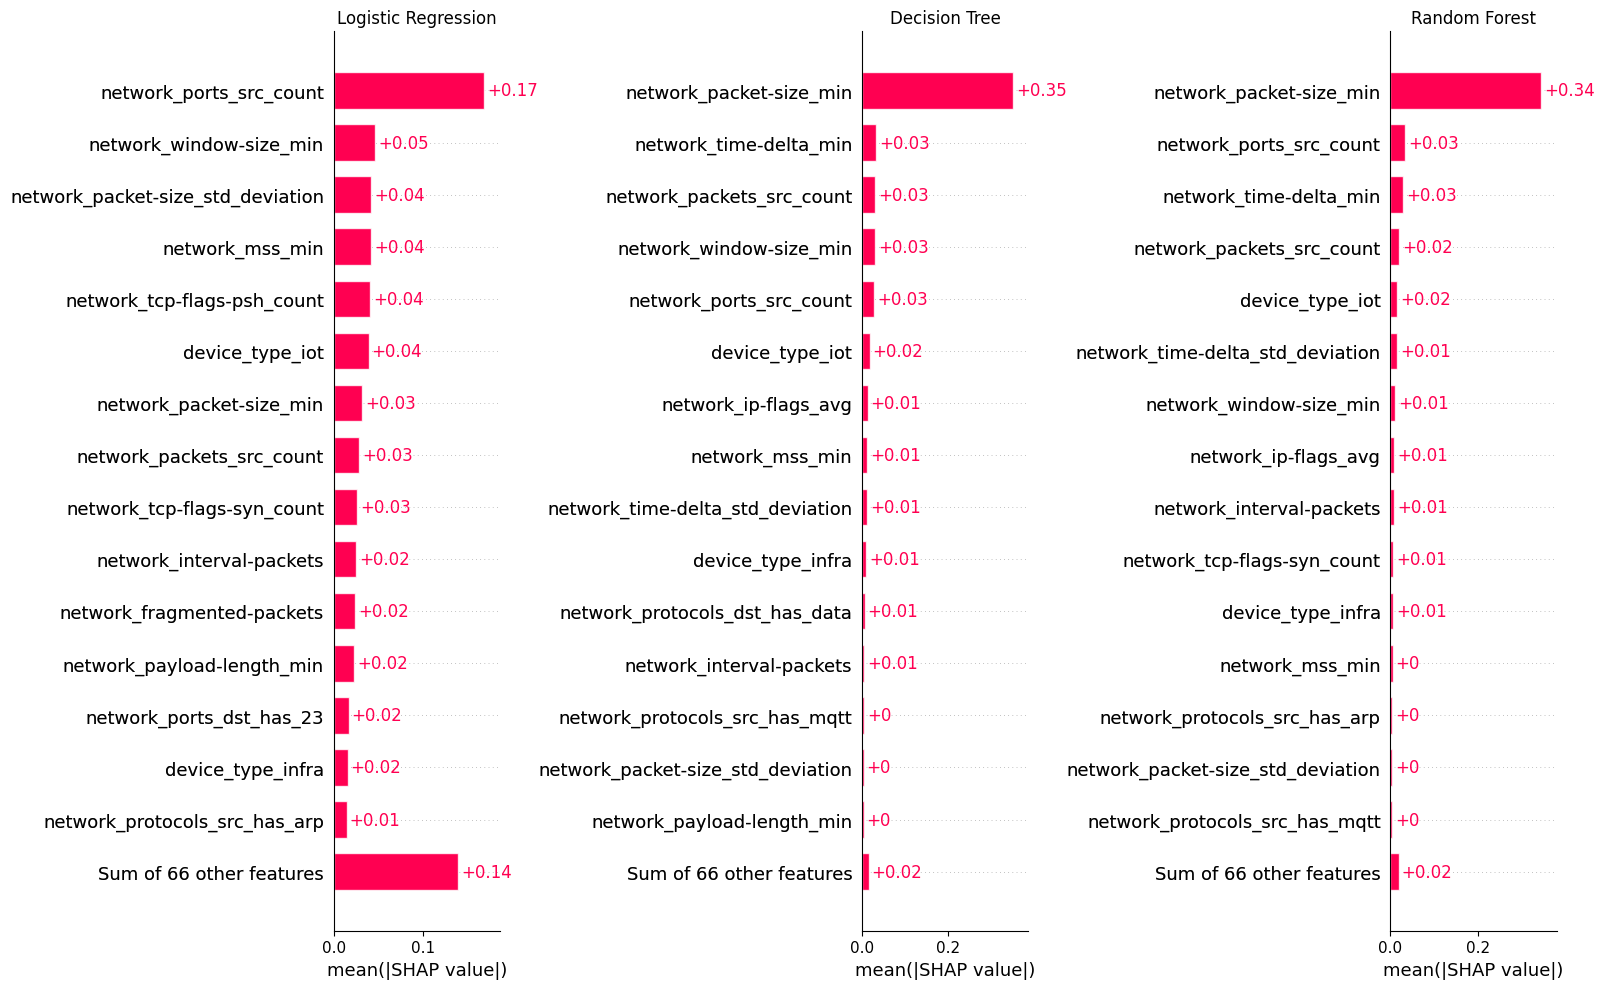

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(16, 10))

for i, model_name in enumerate(shap_values["binary"]):
    values = shap_values["binary"][model_name]
    shap.plots.bar(
        shap_values=values[:, :, 0],
        max_display=16,
        ax=axs[i],
        show=False,
    )
    axs[i].set_title(model_pretty_name(model_name))

plt.tight_layout()
fig.savefig(
    SHAP_DIR / "detec_general_abs_importances.png",
    dpi=300, bbox_inches="tight",
)
plt.show()

### Mean signed importances

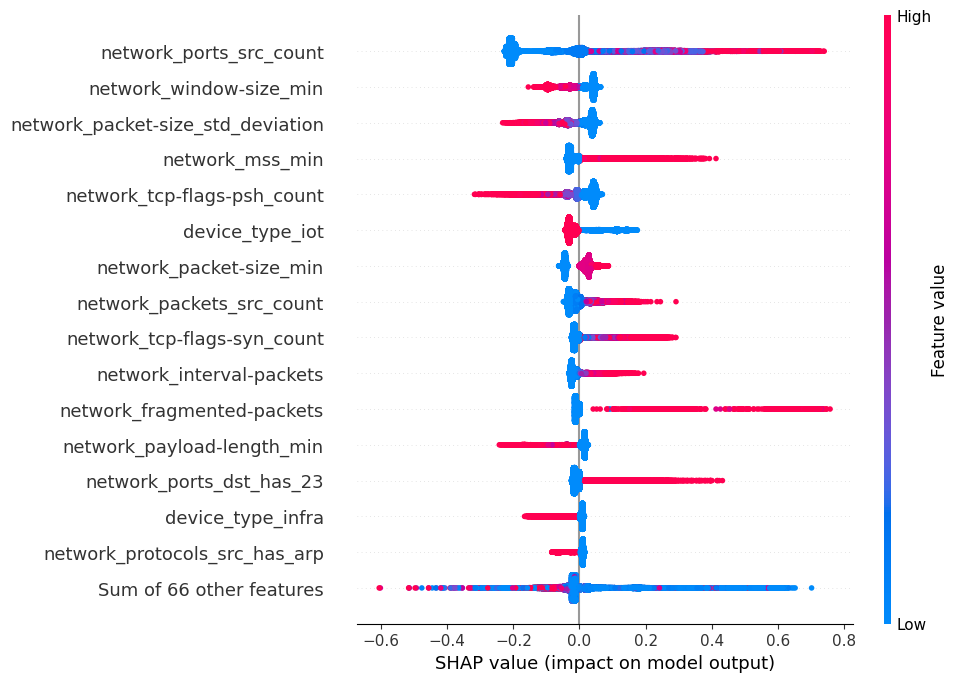

In [10]:
fig, ax = plt.subplots()
plt.sca(ax)

values = shap_values["binary"]["logistic_regression"]

ax = shap.plots.beeswarm(
    shap_values=values[:, :, 0],
    max_display=16,
    show=False,
)

fig.savefig(
    SHAP_DIR / "detec_general_sig_importances_logistic.png",
    dpi=300, bbox_inches="tight",
)
plt.show()

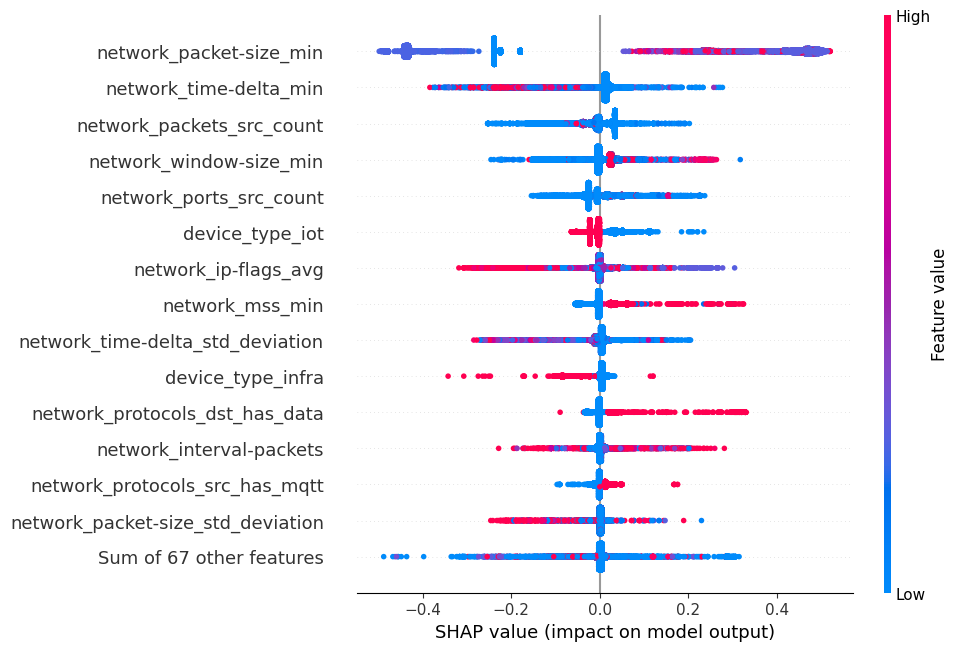

In [11]:
fig, ax = plt.subplots()
plt.sca(ax)

values = shap_values["binary"]["decision_tree"]

ax = shap.plots.beeswarm(
    shap_values=values[:, :, 0],
    max_display=15,
    show=False,
)

fig.savefig(
    SHAP_DIR / "detec_general_sig_importances_tree.png",
    dpi=300, bbox_inches="tight",
)
plt.show()

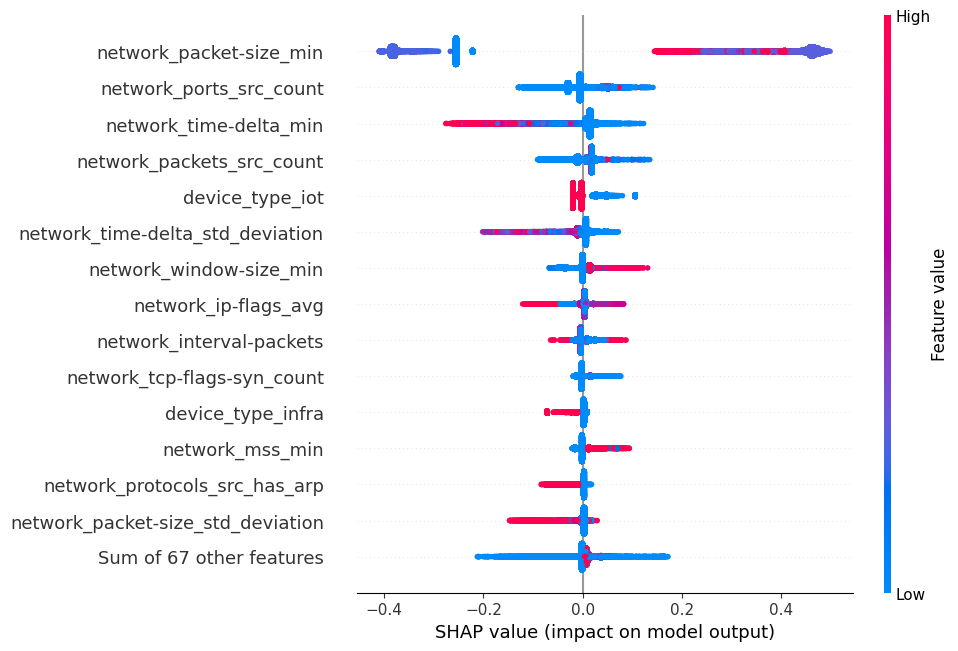

In [12]:
fig, ax = plt.subplots()
plt.sca(ax)

values = shap_values["binary"]["random_forest"]

ax = shap.plots.beeswarm(
    shap_values=values[:, :, 0],
    max_display=15,
    show=False,
)

fig.savefig(
    SHAP_DIR / "detec_general_sig_importances_forest.png",
    dpi=300, bbox_inches="tight",
)
plt.show()

## Attack classification

### Mean absolute importances

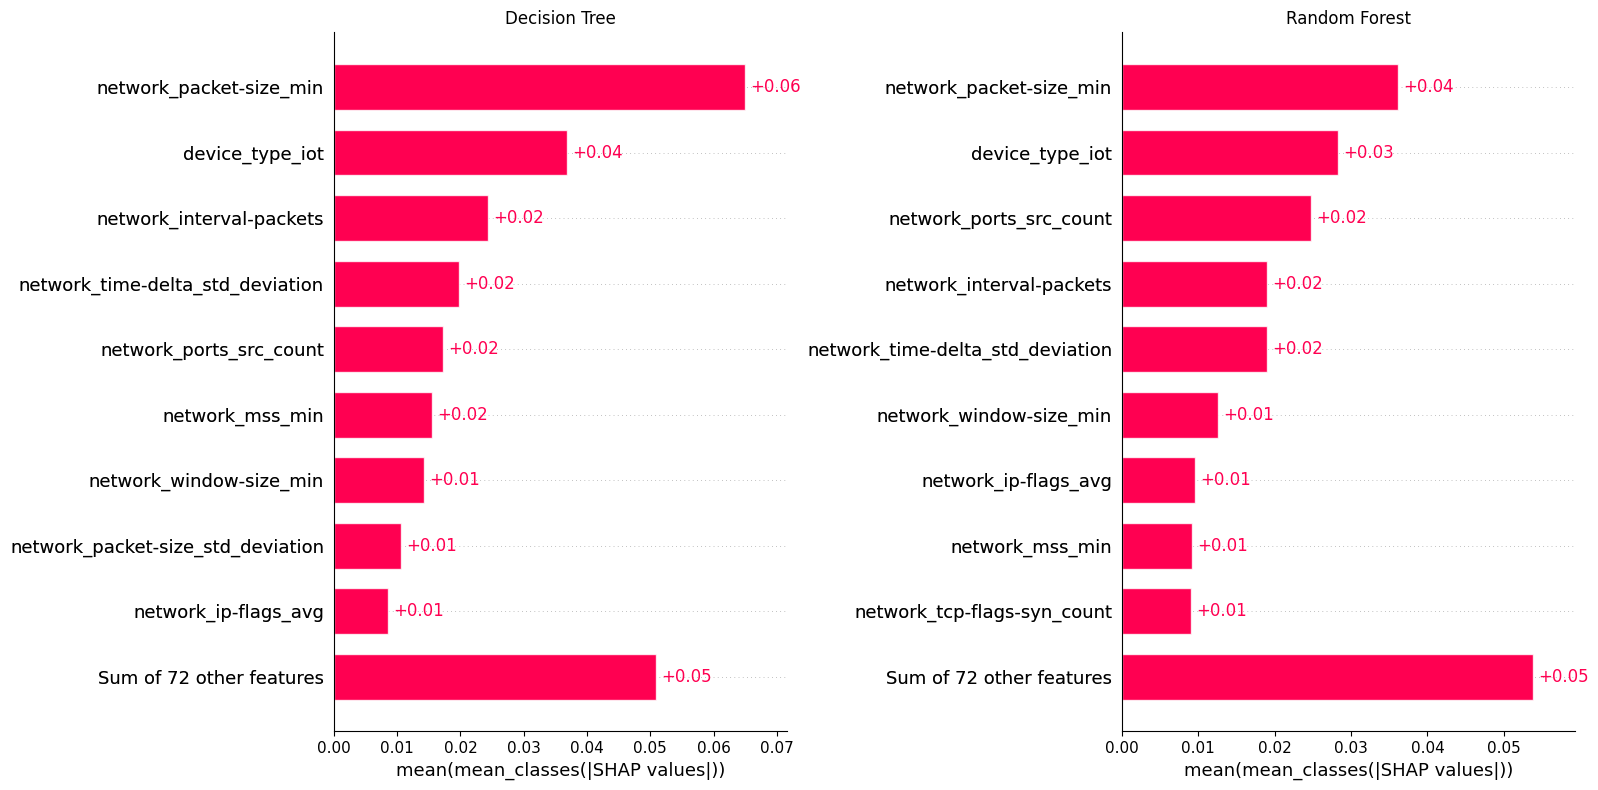

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(16, 8))

for i, model_name in enumerate(("decision_tree", "random_forest")):
    ax = axs[i]
    values = shap_values["condensed"][model_name]
    shap.plots.bar(
        shap_values=values.abs.mean(2),
        max_display=10,
        ax=ax,
        show=False,
    )
    ax.set_xlabel("mean(mean_classes(|SHAP values|))")
    ax.set_title(model_pretty_name(model_name))

plt.tight_layout()
fig.savefig(
    SHAP_DIR / "classific_general_abs_importances.png",
    dpi=300, bbox_inches="tight",
)
plt.show()

### Mean signed importances

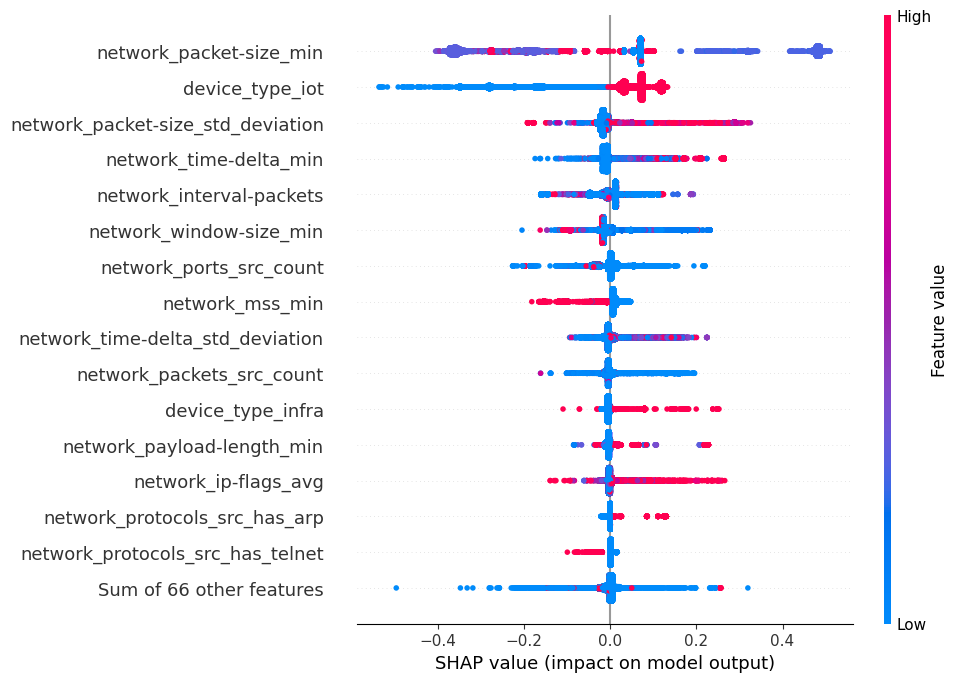

In [14]:
fig, ax = plt.subplots()
plt.sca(ax)

values = shap_values["condensed"]["decision_tree"]

ax = shap.plots.beeswarm(
    shap_values=values[:, :, 0],
    max_display=16,
    show=False,
)

fig.savefig(
    SHAP_DIR / "classific_general_sig_importances_tree.png",
    dpi=300, bbox_inches="tight",
)
plt.show()

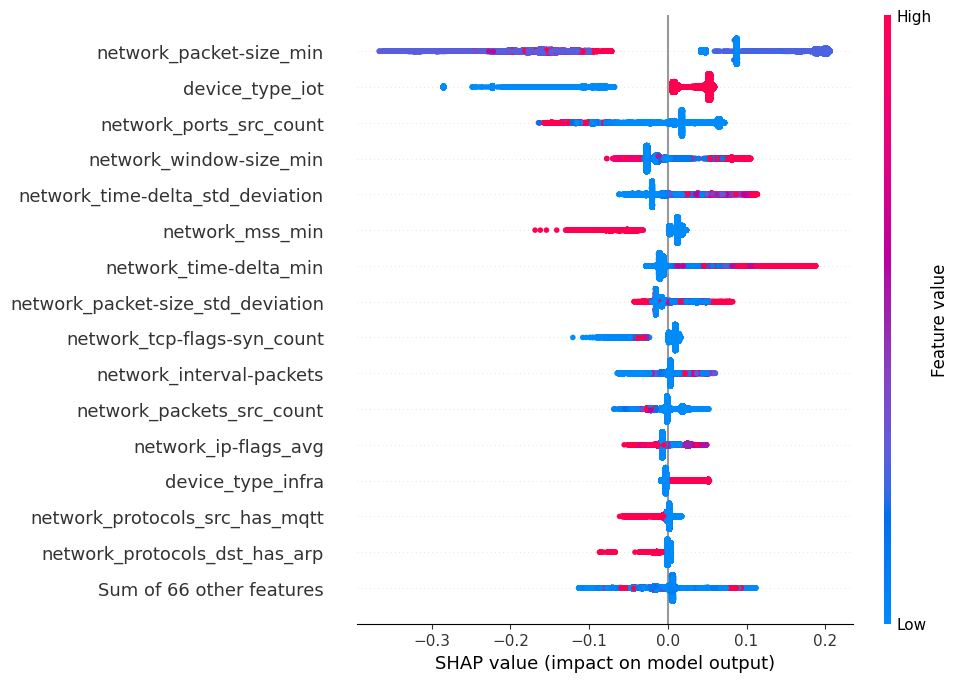

In [15]:
fig, ax = plt.subplots()
plt.sca(ax)

values = shap_values["condensed"]["random_forest"]

ax = shap.plots.beeswarm(
    shap_values=values[:, :, 0],
    max_display=16,
    show=False,
)

fig.savefig(
    SHAP_DIR / "classific_general_sig_importances_forest.png",
    dpi=300, bbox_inches="tight",
)
plt.show()

### Mean absolute importances per class

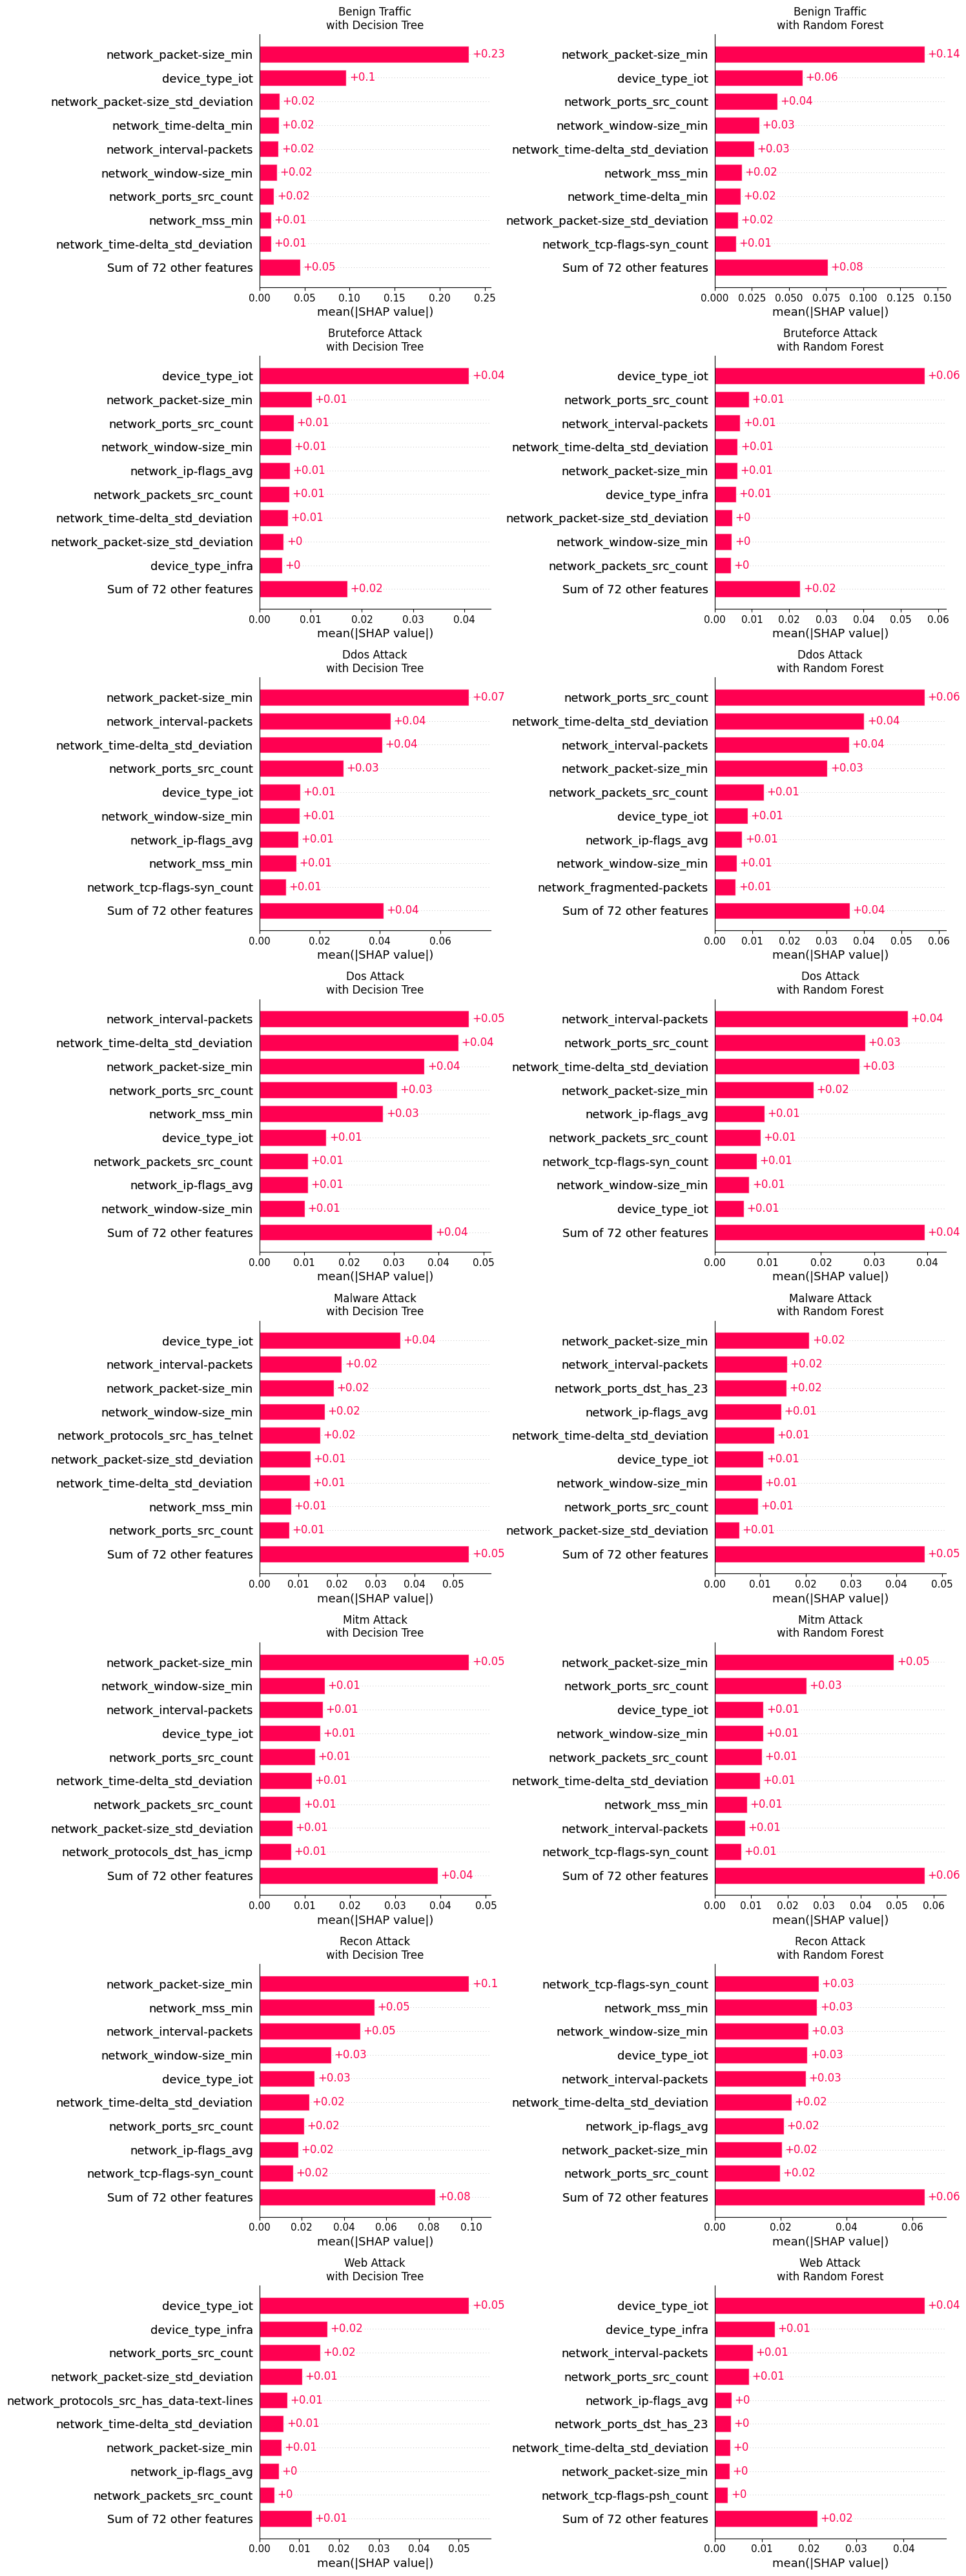

In [16]:
fig, axs = plt.subplots(8, 2, figsize=(15, 40))

class_names = models["condensed"]["decision_tree"].classes_

for i, model_name in enumerate(("decision_tree", "random_forest")):
    values = shap_values["condensed"][model_name]
    for j, class_name in enumerate(class_names):
        ax = axs[j, i]
        shap.plots.bar(
            shap_values=values[:, :, j],
            max_display=10,
            ax=ax,
            show=False,
        )
        ax.set_title(
            "{} {}\nwith {}".format(
                class_name.capitalize(),
                "Traffic" if class_name == "benign" else "Attack",
                model_pretty_name(model_name),
            )
        )

plt.tight_layout()
fig.savefig(
    SHAP_DIR / "classific_importances_per_class.png",
    dpi=300, bbox_inches="tight",
)
plt.show()

# Error explanations

## Attack detection

In [17]:
rf_model = models["binary"]["random_forest"]
rf_data = data["binary"]["random_forest"][1]
values = shap_values["binary"]["random_forest"]

In [18]:
pos_label = "attack"
rf_pred = (rf_model.predict(rf_data) == pos_label)
ground_truth = (X_test["label1"] == pos_label)

# Correct predictions
tps = rf_pred & ground_truth
tns = ~(rf_pred | ground_truth)

# Wrong predictions
fps = rf_pred & ~ground_truth
fns = ~rf_pred & ground_truth

In [19]:
# For randomly choosing a sample
rng = np.random.default_rng(RANDOM_SEED)

### TPs explanation

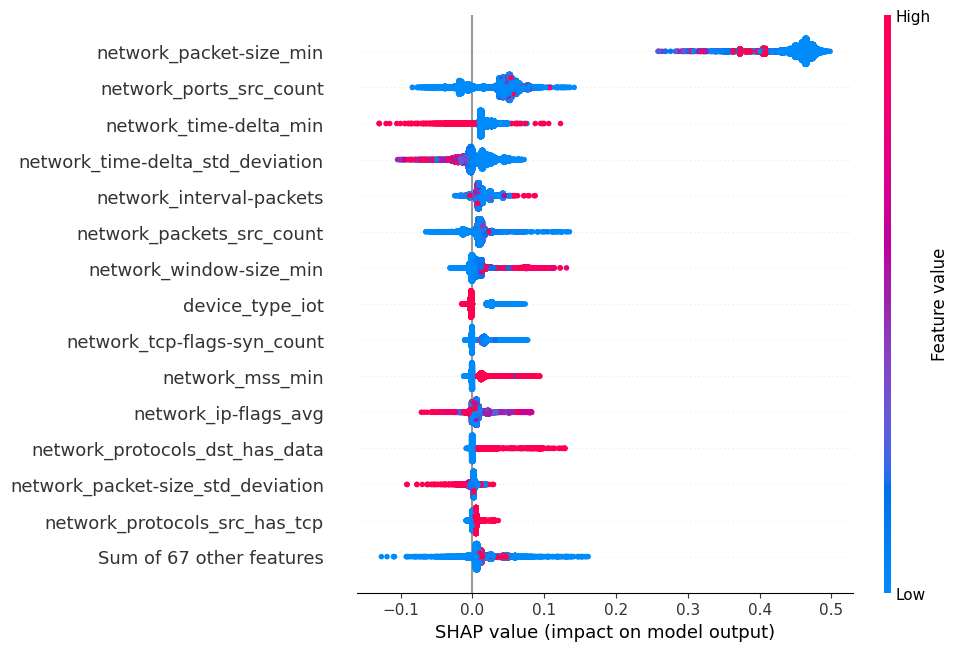

In [20]:
fig, ax = plt.subplots()
plt.sca(ax)

ax = shap.plots.beeswarm(
    values[tps.values, :, 0],
    max_display=15,
    show=False,
)

fig.savefig(
    SHAP_DIR / "detec_cm_tp_importances.png",
    dpi=300, bbox_inches="tight",
)
plt.show()

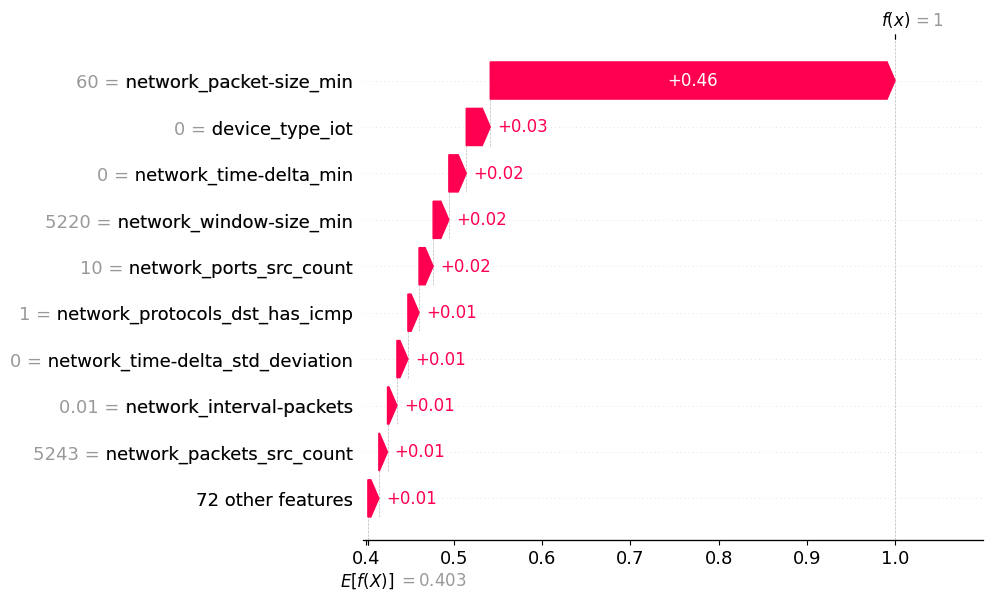

In [21]:
fig, ax = plt.subplots()
plt.sca(ax)

tp_sample = rng.choice(np.nonzero(tps)[0], size=1).item()
shap.plots.waterfall(values[tp_sample, :, 0], show=False)

fig.savefig(
    SHAP_DIR / "detec_cm_tp_waterfall.png",
    dpi=300, bbox_inches="tight",
)
plt.show()


### TNs explanation

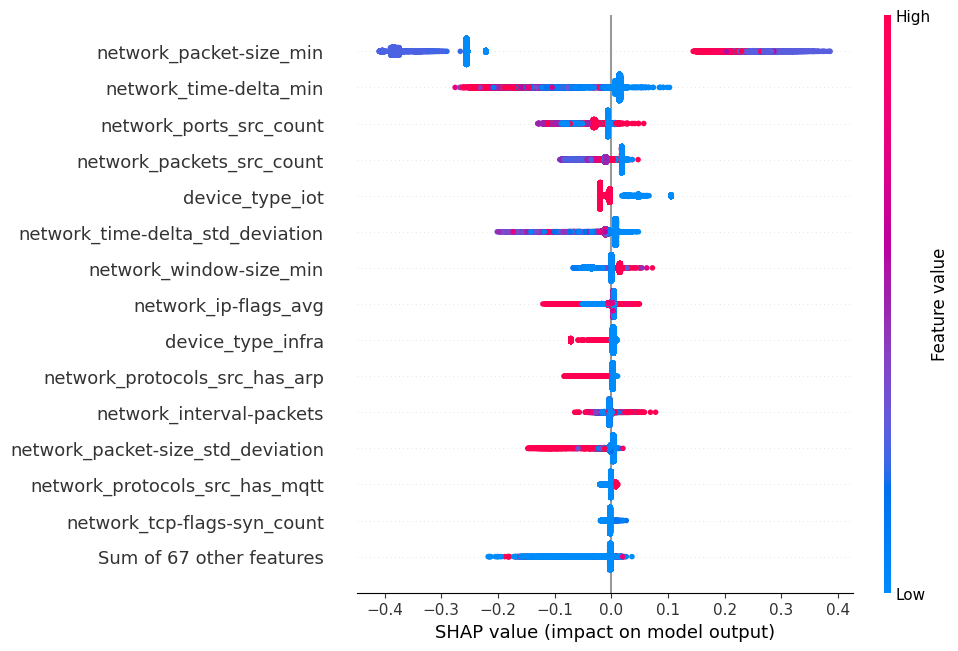

In [22]:
fig, ax = plt.subplots()
plt.sca(ax)

ax = shap.plots.beeswarm(
    values[tns.values, :, 0],
    max_display=15,
    show=False,
)

fig.savefig(
    SHAP_DIR / "detec_cm_tn_importances.png",
    dpi=300, bbox_inches="tight",
)
plt.show()

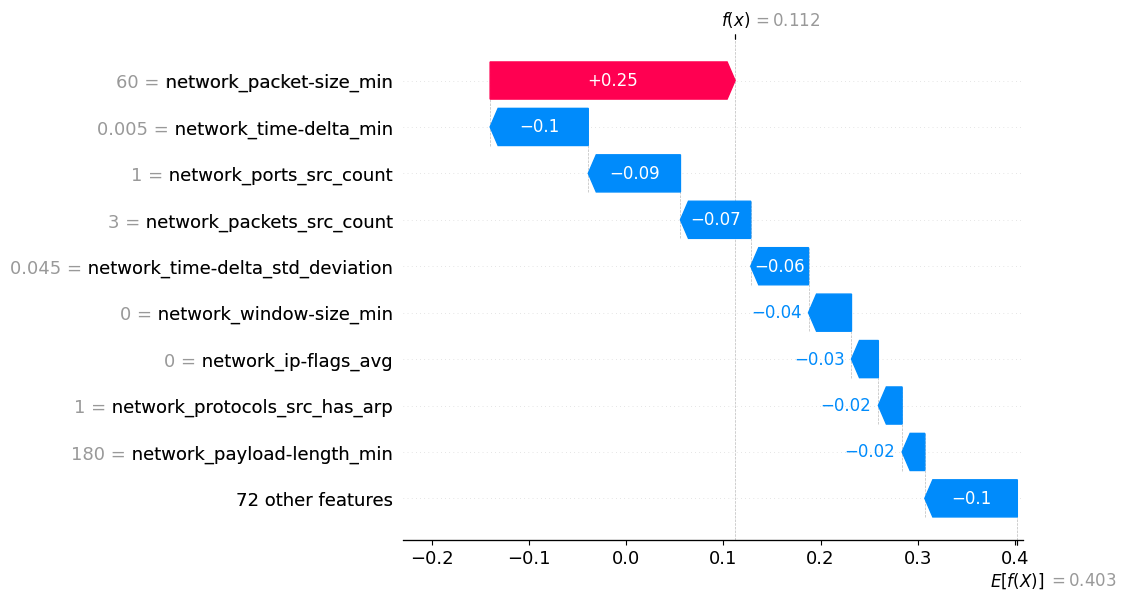

In [23]:
fig, ax = plt.subplots()
plt.sca(ax)

tp_sample = rng.choice(np.nonzero(tns)[0], size=1).item()
shap.plots.waterfall(values[tp_sample, :, 0], show=False)

fig.savefig(
    SHAP_DIR / "detec_cm_tn_waterfall.png",
    dpi=300, bbox_inches="tight",
)
plt.show()


### FPs explanation

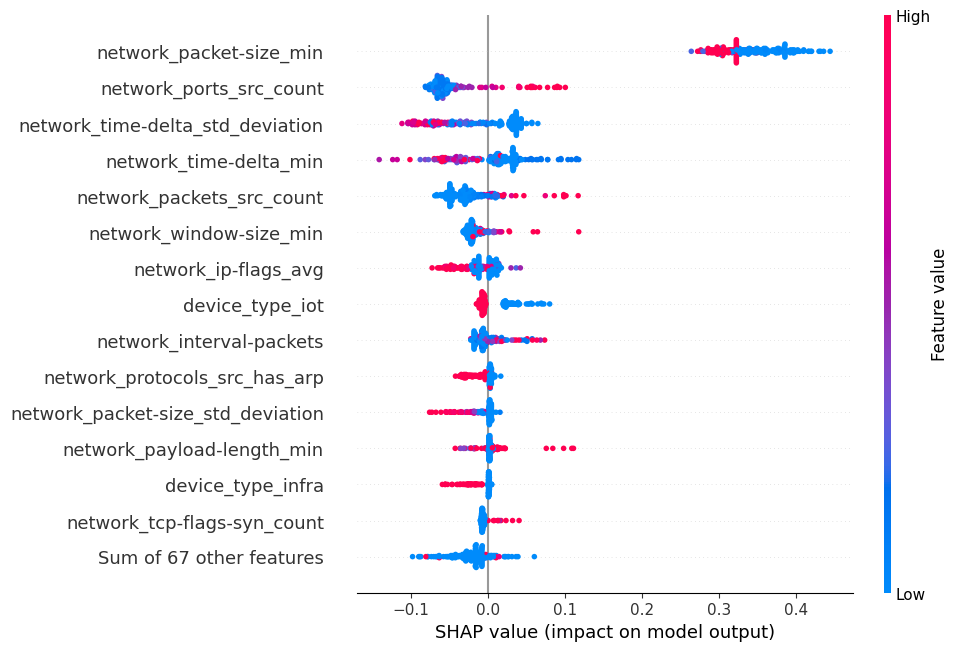

In [24]:
fig, ax = plt.subplots()
plt.sca(ax)

ax = shap.plots.beeswarm(
    values[fps.values, :, 0],
    max_display=15,
    show=False,
)

fig.savefig(
    SHAP_DIR / "detec_cm_fp_importances.png",
    dpi=300, bbox_inches="tight",
)
plt.show()

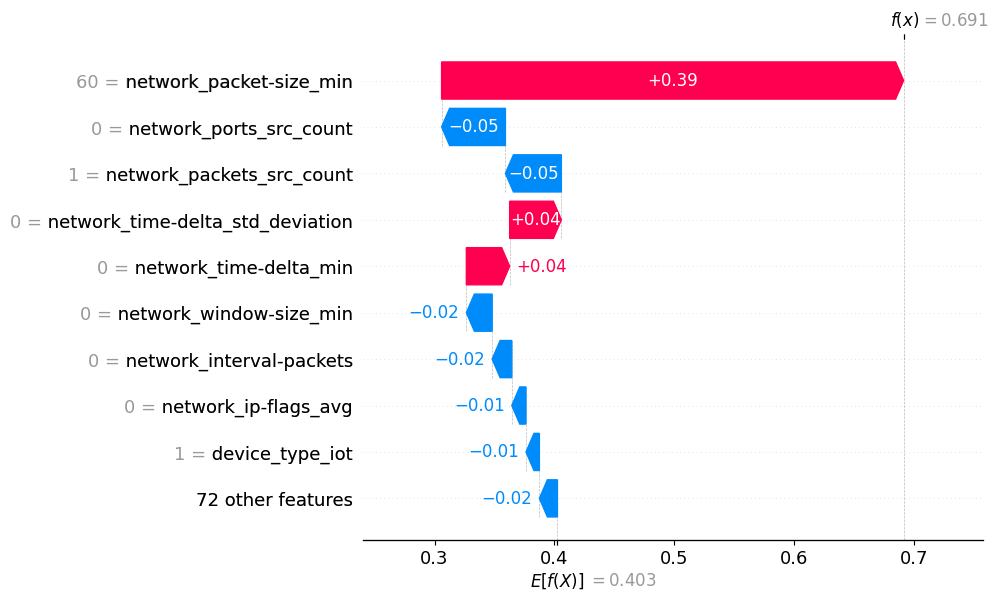

In [25]:
fig, ax = plt.subplots()
plt.sca(ax)

tp_sample = rng.choice(np.nonzero(fps)[0], size=1).item()
shap.plots.waterfall(values[tp_sample, :, 0], show=False)

fig.savefig(
    SHAP_DIR / "detec_cm_fp_waterfall.png",
    dpi=300, bbox_inches="tight",
)
plt.show()


### FNs explanation

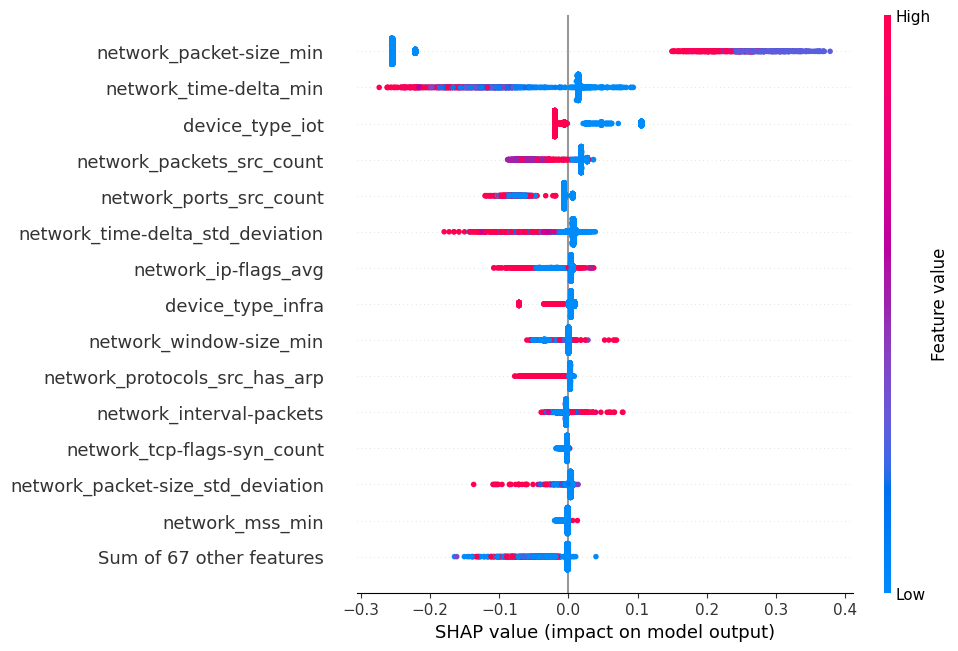

In [26]:
fig, ax = plt.subplots()
plt.sca(ax)

ax = shap.plots.beeswarm(
    values[fns.values, :, 0],
    max_display=15,
    show=False,
)

fig.savefig(
    SHAP_DIR / "detec_cm_fn_importances.png",
    dpi=300, bbox_inches="tight",
)
plt.show()

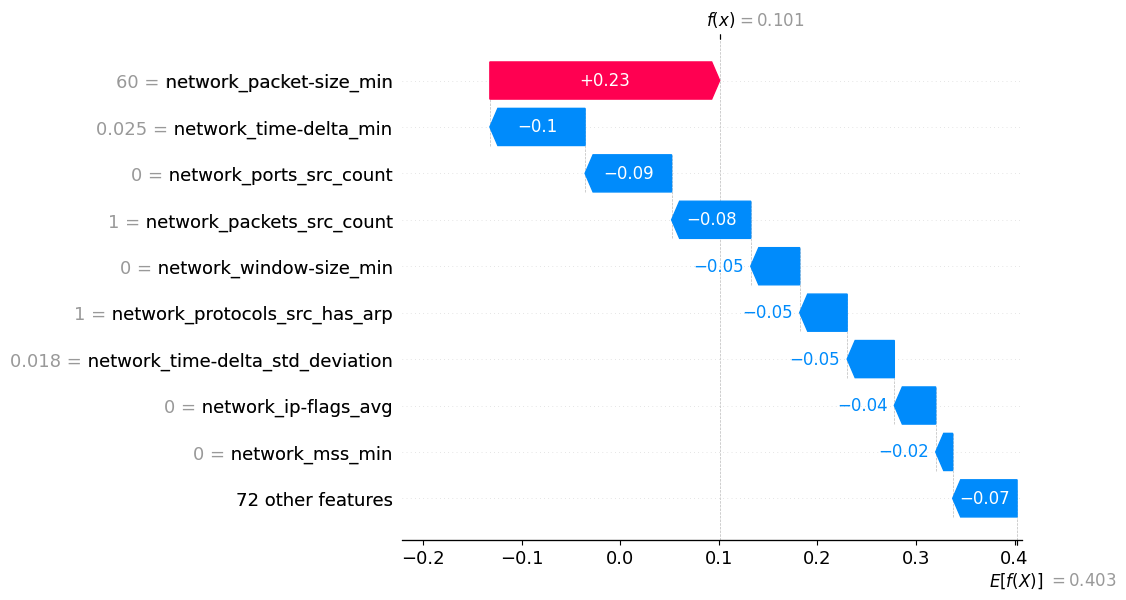

In [27]:
fig, ax = plt.subplots()
plt.sca(ax)

tp_sample = rng.choice(np.nonzero(fns)[0], size=1).item()
shap.plots.waterfall(values[tp_sample, :, 0], show=False)

fig.savefig(
    SHAP_DIR / "detec_cm_fn_waterfall.png",
    dpi=300, bbox_inches="tight",
)
plt.show()
